# Chapter 5: The Filter
A hidden random walk is observed through noisy measurements. We implement the
scalar Kalman prediction/update and backward smoother directly so every variance
calculation is inspectable. This is simulated tracking data, not an Apollo record.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(5)
Q,R=.2,2.; n=120
truth=np.cumsum(rng.normal(0,np.sqrt(Q),n)); observed=truth+rng.normal(0,np.sqrt(R),n)

## Prediction uncertainty grows; observation reduces it
Fixed Q and R imply gain depends on covariance, not directly on shock size.
A large residual alone does not automatically make this filter adaptive.

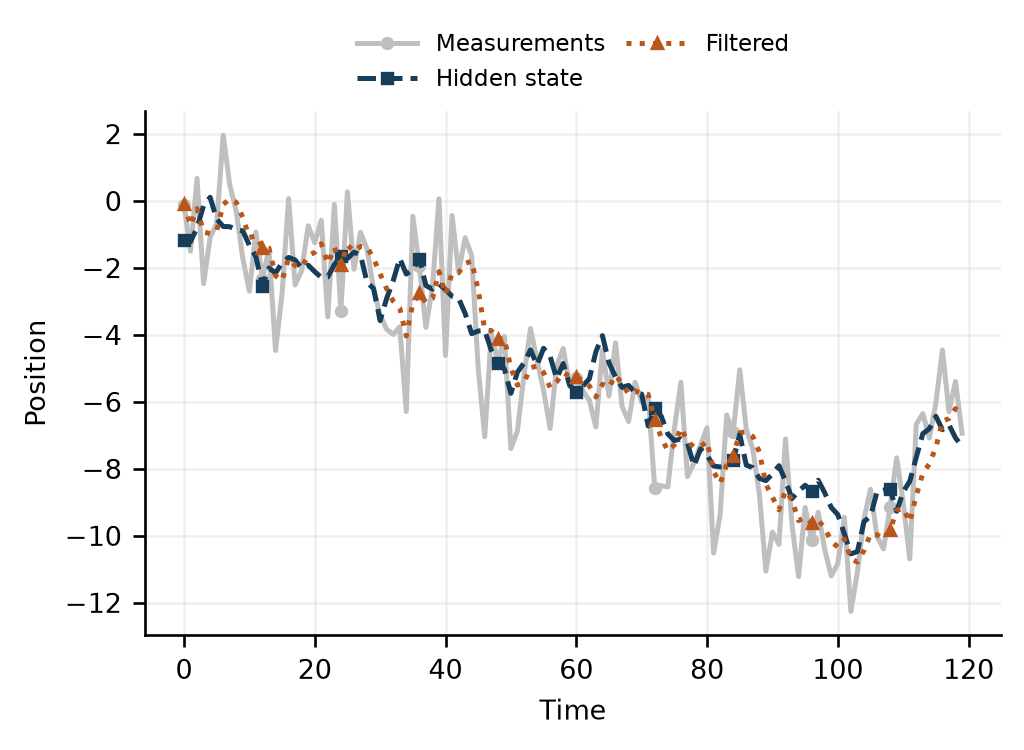

In [2]:
means=[]; variances=[]; innovations=[]; innovation_var=[]; m,P=0.,5.
for z in observed:
    predP=P+Q; innovation=z-m; K=predP/(predP+R)
    innovations.append(innovation); innovation_var.append(predP+R)
    m=m+K*innovation; P=(1-K)*predP
    means.append(m); variances.append(P)
means=np.array(means); variances=np.array(variances)
assert np.all(variances>0)
plt.figure(); plt.plot(observed,color='.75',label='Measurements'); plt.plot(truth,label='Hidden state'); plt.plot(means,label='Filtered'); plt.xlabel('Time'); plt.ylabel('Position'); plt.legend(fontsize=7)
save(5,1,'Tracking what cannot be directly observed','Synthetic random walk with measurement noise. The filter uses observations available at each time; the true state is shown only for evaluation.','## The State-Space Framework')

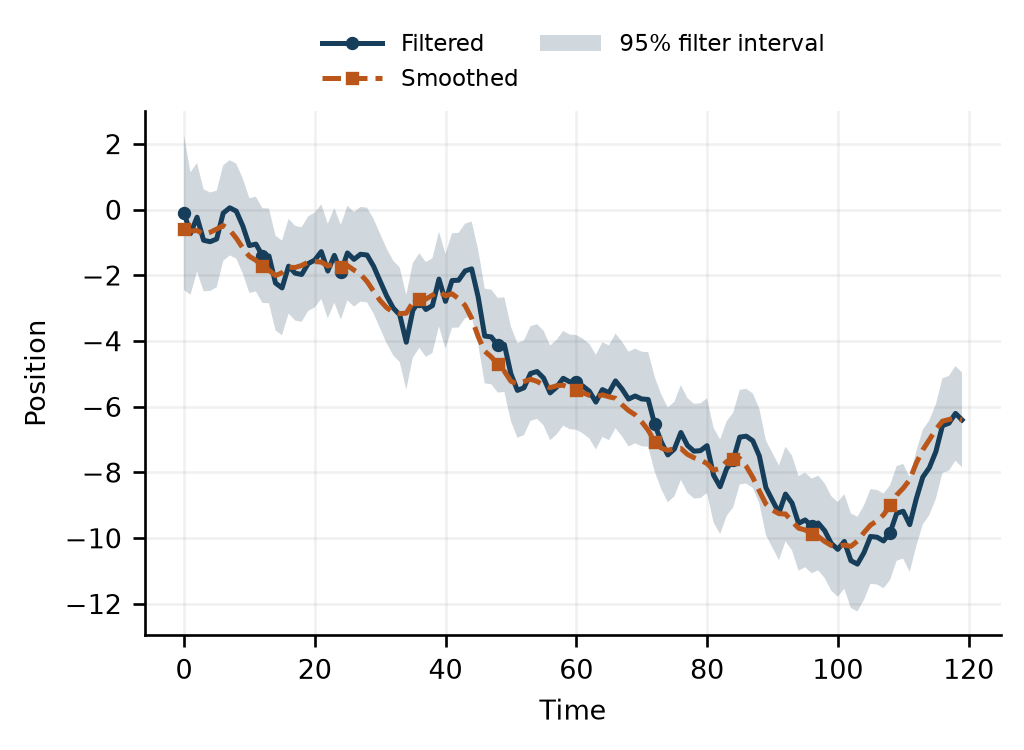

In [3]:
smooth=means.copy()
for t in range(n-2,-1,-1): smooth[t]=means[t]+variances[t]/(variances[t]+Q)*(smooth[t+1]-means[t])
plt.figure(); plt.plot(means,label='Filtered'); plt.plot(smooth,label='Smoothed'); plt.fill_between(np.arange(n),means-1.96*np.sqrt(variances),means+1.96*np.sqrt(variances),alpha=.2,label='95% filter interval'); plt.xlabel('Time'); plt.ylabel('Position'); plt.legend(fontsize=7)
save(5,2,'Filtering and smoothing answer different questions','Synthetic tracking example. The smoother uses future measurements retrospectively; the shaded interval belongs to the online filter.','## The Methods')

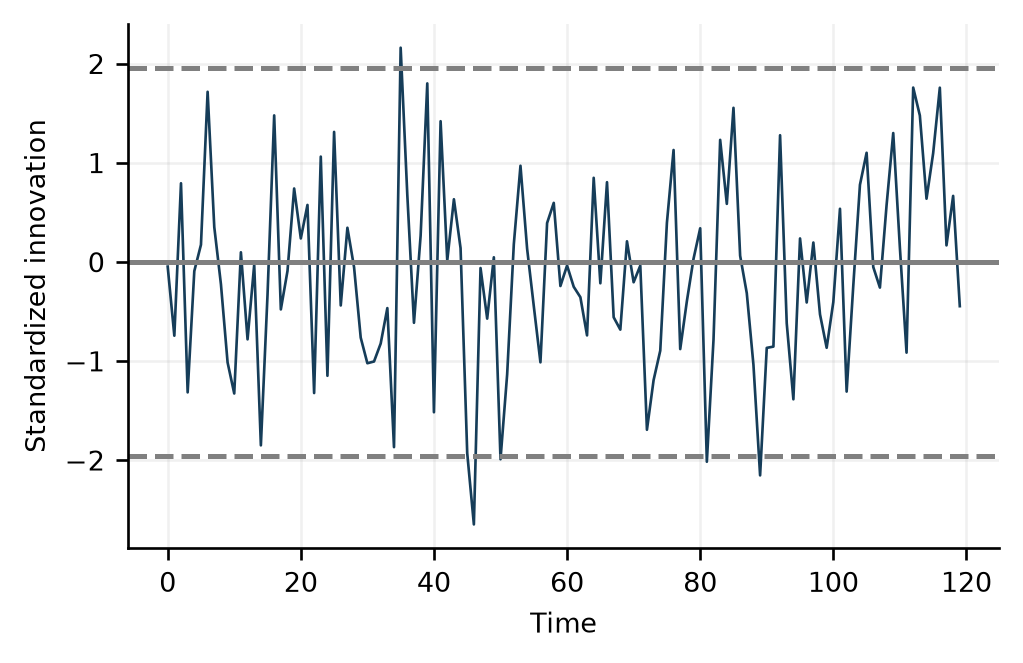

Filtered RMSE 0.7666785505911996 smoothed 0.5873743099171755


In [4]:
standardized=np.array(innovations)/np.sqrt(innovation_var)
plt.figure(); plt.plot(standardized,lw=.8); plt.axhline(0,color='.5'); plt.axhline(1.96,ls='--',color='.5'); plt.axhline(-1.96,ls='--',color='.5'); plt.xlabel('Time'); plt.ylabel('Standardized innovation')
save(5,3,'Listen to the innovations','Standardized one-step prediction errors from the synthetic filter. Persistent patterns would question the assumed state or noise model.','## What You Cannot See But Must Estimate')
print('Filtered RMSE',np.sqrt(np.mean((means-truth)**2)),'smoothed',np.sqrt(np.mean((smooth-truth)**2)))

## Noise assumptions change both tracking and coverage
Refilter the same observations under three assumed measurement variances.
The generator's R=2 is known only because this is a controlled experiment.
Coverage here is the fraction of latent states inside marginal filter bands
on this one dependent path, not an operational calibration guarantee.

In [5]:
for assumed_R in [.2, 2., 20.]:
    estimate, variance = 0., 5.
    fitted, lower, upper = [], [], []
    for observation in observed:
        prior_variance = variance+Q
        gain = prior_variance/(prior_variance+assumed_R)
        estimate += gain*(observation-estimate)
        variance = (1-gain)*prior_variance
        fitted.append(estimate)
        lower.append(estimate-1.96*np.sqrt(variance))
        upper.append(estimate+1.96*np.sqrt(variance))
    coverage = np.mean((truth >= lower) & (truth <= upper))
    print({'assumed_R': assumed_R, 'state_RMSE': float(np.sqrt(np.mean((truth-fitted)**2))),
           'nominal_95_coverage': float(coverage), 'mean_width': float(np.mean(np.array(upper)-lower))})

{'assumed_R': 0.2, 'state_RMSE': 1.0401922794282192, 'nominal_95_coverage': 0.4583333333333333, 'mean_width': 1.3815103451256308}
{'assumed_R': 2.0, 'state_RMSE': 0.7666785505911996, 'nominal_95_coverage': 0.95, 'mean_width': 2.9111051333615325}
{'assumed_R': 20.0, 'state_RMSE': 0.8947798151766599, 'nominal_95_coverage': 1.0, 'mean_width': 5.5121754851365115}


## Limits and exercise
Increase measurement variance without telling the filter: inspect coverage and
innovations. Dynamic factor models, BSTS, BVAR and cohort-component models extend
the state structure; they are not represented by renaming this scalar example.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A regular series of at least 30 observed values; the target cell may be empty where an observation is missing, and the filter carries the state across the gap. `model` is `local level`, `local linear trend`, `smooth trend` or `local_level_manual` (the hand-rolled filter with fixed `Q` and `R`, complete data only). Set `seasonal` true to add a seasonal component with period `season`, and `cycle` for a stochastic cycle.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,target
2010-01-01,41.3
2010-02-01,
2010-03-01,44.9
```

## Explain the mechanism

The Kalman gain is a precision tradeoff. A noisy sensor gets less weight; a volatile state makes the previous estimate less reliable. The filter uses information through now; a smoother uses later observations to reconstruct the past.

## Work through the arithmetic

Prior m=10,P=4, process Q=1 and measurement R=5 give predicted variance 5 and gain .5. Seeing z=14 updates m to 12 and P to 2.5. One-step future state variance is 3.5; future observation variance is 8.5. Using 3.5 for a measurement interval would omit sensor noise.

## Adapt the lesson to reader data

Replace observed in the filter block; retain truth only for controlled simulation. Record missing measurements explicitly and skip their update. The supplied source uses fixed Q,R; changing them requires documenting how they were estimated or specifying sensitivity scenarios.

For this chapter, settle these questions before fitting: What latent state is being measured? What are measurement units and timing? How were process variance Q and measurement variance R estimated? Are missing observations or changing sensor quality expected?

## Interpret the actual lesson outputs

The latent truth line exists because the example is simulated. Its filter and smoother RMSE comparison is not available from ordinary sensor readings alone. The 95% shaded band belongs to the online filter, not the smoother. Noise-sensitivity coverage uses one dependent path and does not certify deployment calibration.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,kind,estimate,lower,upper`.
- `summary.json`: `model,seasonal,cycle,params,llf,missing_count,missing_timestamps,ljung_box_p,validation,test_mae,horizon` plus method, interpretation, assumptions, not_done and status.

The tool fits a statsmodels unobserved-components model with the chosen level dynamics, optional seasonal and cycle components, and missing observations handled by the Kalman filter; it returns the filtered level (past data only), the smoothed level (all data, retrospective) with 80 percent bands, and an `horizon`-step forecast with its interval, plus the estimated variances, log likelihood, the timestamps that were missing, a Ljung-Box test on second-half standardised innovations, and a rolling check at `origins` expanding origins against the last observed value. Regression effects and non-Gaussian filters are not attempted. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Check innovation bias, correlation and variance against assumptions. Large residuals do not automatically increase the gain when Q,R are fixed. State intervals and observation intervals answer different questions; real latent-state coverage cannot be measured without independent truth.

At a missing measurement perform prediction only and let uncertainty grow. Without known Q,R use sensitivity cases or train-only estimation, not the generator’s hidden truth. If linear/Gaussian assumptions fail, route to a separately implemented richer state model.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,kind,estimate,lower,upper`; `summary.json` keys: `model,seasonal,cycle,params,llf,missing_count,missing_timestamps,ljung_box_p,validation,test_mae,horizon` plus method, interpretation, assumptions, not_done and status. Never present the smoothed path as what could have been known at the time; the filtered path is the real-time estimate.

## Three exercises with worked solutions

### Exercise 1

Predicted variance 9 and R=3: gain?

**Worked solution.** 9/(9+3)=.75, so three quarters of the innovation updates the state.

### Exercise 2

What happens to uncertainty during two missing readings with Q=2?

**Worked solution.** Without updates, state variance increases by 4.

### Exercise 3

Can lower smoothed RMSE justify replacing recorded online predictions?

**Worked solution.** No. Smoothing uses later measurements; preserve the forecasts actually available at each origin.

## Business-reader application

Use this request with the skill:

> Use chapter 5 to track the latent level in readings.csv, explain Q and R, retain online predictions and distinguish state uncertainty from observation uncertainty.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/annual-nile.csv) and [matching config](../configs/ch05-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 5 \
  --input companion/data/observed/annual-nile.csv \
  --config companion/configs/ch05-observed.json \
  --output companion/applied-runs/ch05-observed-reader
```

Inspect the standardized-innovation diagnostic and explain whether the local-level model leaves persistent structure. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch05.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch05.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(5, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch05-workshop-results.csv', index=False)
_ = (workshop_output/'ch05-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: UnobservedComponents state-space model
Status: passed

Interpretation: local level + seasonal(12) fitted with 5 missing observations handled by the filter. Rolling check over 3 origins: model MAE 1.93 vs last-value 6.695. Ljung-Box p on second-half innovations 0.33. Smoothed states use later observations and are retrospective; filtered states and forecasts use only the past.

Assumptions:
  - Gaussian state and measurement noise
  - local level dynamics, deterministic-period seasonality
  - Missing values are missing at random
Not done:
  - No regression effects or exogenous inputs
  - Nonlinear or non-Gaussian filtering not attempted

Evidence:
  model: local level
  seasonal: True
  cycle: False
  params: sigma2.irregular=4.104, sigma2.level=0.1909, sigma2.seasonal=3.002e-10
  llf: -297.4
  missing_count: 5
  missing_timestamps: [2011-09-01 00:00:00+00:00, 2011-10-01 00:00:00+00:00, 2014-10-01 00:00:00+00:00, 2017-07-01 00:00:00+00:00, 2020-01-01 00:00:00+00:00]
  ljung_box_p

## The same workflow on observed data

A second run on a bundled public-domain series documented in `data/registry.json` (a revised
historical snapshot, not an archived real-time vintage). The earlier time cuts prevent fitting
on held-out outcomes; they do not undo revisions made before the snapshot was published.
Compare this digest with the controlled case above: a method need not win to be useful, and
the winner on synthetic data has no claim on observed data.

In [7]:
observed_input = pd.read_csv(project_path/'companion/data/observed/annual-nile.csv')
observed_config = json.loads((project_path/'companion/configs/ch05-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(5, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(summarize(observed_summary, observed_table))
print()
print(preview(observed_table))
observed_table.to_csv(workshop_output/'ch05-observed-results.csv', index=False)
_ = (workshop_output/'ch05-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels Nile annual flow, 1871–1970
Method: UnobservedComponents state-space model
Status: passed

Interpretation: local level fitted with 0 missing observations handled by the filter. Rolling check over 3 origins: model MAE 81.62 vs last-value 124.5. Ljung-Box p on second-half innovations 0.68. Smoothed states use later observations and are retrospective; filtered states and forecasts use only the past.

Assumptions:
  - Gaussian state and measurement noise
  - local level dynamics
  - Missing values are missing at random
Not done:
  - No regression effects or exogenous inputs
  - Nonlinear or non-Gaussian filtering not attempted

Evidence:
  model: local level
  seasonal: False
  cycle: False
  params: sigma2.irregular=1.508e+04, sigma2.level=1479
  llf: -632.5
  missing_count: 0
  missing_timestamps: []
  ljung_box_p: 0.6835
  validation: <3 rows>
  test_mae: 81.62
  horizon: 10

Table: 210 rows, columns ['timestamp', 'kind', 'estimate', 'lowe

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **Is the filtered path or the smoothed path the one the decision needs, and did I mix them?**
   A bad answer looks like this: Reporting the smoothed path as what was known in real time credits the model with hindsight.

2. **Do the innovations look like noise, or is the model missing a component?**
   A bad answer looks like this: Autocorrelated innovations mean the state equations are wrong, not that the noise is large.

3. **How were the noise variances chosen, and would doubling them change the band materially?**
   A bad answer looks like this: Noise variances tuned on the whole series and then quoted as if fixed in advance overstate the band's meaning.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).